In [6]:
from pytrends.request import TrendReq
import pandas as pd
import os

pytrends = TrendReq()
keywords = ["delete facebook", "facebook privacy", "cambridge analytica"]

def get_trends(timeframe):
    pytrends.build_payload(keywords, timeframe=timeframe)
    df = pytrends.interest_over_time()
    df = df.drop(columns=["isPartial"], errors="ignore")
    df = df.reset_index()
    return df

df1 = get_trends("2015-01-01 2017-12-31")
df2 = get_trends("2018-01-01 2019-12-31")
df3 = get_trends("2020-01-01 2021-12-31")

all_trends = pd.concat([df1, df2, df3], ignore_index=True)
all_trends["date"] = pd.to_datetime(all_trends["date"])
all_trends = all_trends.drop_duplicates(subset="date")
all_trends = all_trends.sort_values("date").reset_index(drop=True)

os.makedirs("data/raw", exist_ok=True)
all_trends.to_csv("data/raw/google_trends_2015_2021.csv", index=False)

all_trends

,date,delete facebook,facebook privacy,cambridge analytica
0,2014-12-28,52,8,0
1,2015-01-04,46,41,0
2,2015-01-11,41,5,0
3,2015-01-18,41,4,0
4,2015-01-25,41,5,0
...,...,...,...,...
361,2021-11-28,53,5,5
362,2021-12-05,55,4,4
363,2021-12-12,52,4,4
364,2021-12-19,51,4,3


In [30]:
import requests
import pandas as pd
import time

def get_wiki_data(page):
    url = f"https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/en.wikipedia/all-access/user/{page}/daily/20150101/20211231"
    
    headers = {
        "User-Agent": "DSA210Project/1.0 (student project)"
    }
    
    response = requests.get(url, headers=headers)
    
    if response.status_code != 200:
        print("Veri alınamadı:", response.status_code)
        print(response.text)
        return None
    
    data = response.json()
    
    records = []
    for item in data["items"]:
        records.append({
            "date": pd.to_datetime(item["timestamp"][:8]),
            f"{page}_views": item["views"]
        })
    
    df = pd.DataFrame(records)
    return df


wiki_ca = get_wiki_data("Cambridge_Analytica")
time.sleep(2)
wiki_fb = get_wiki_data("Facebook")

wiki_ca_weekly = wiki_ca.set_index("date").resample("W").mean().reset_index()
wiki_fb_weekly = wiki_fb.set_index("date").resample("W").mean().reset_index()

wiki_ca_weekly

,date,Cambridge_Analytica_views
0,2016-02-14,23.666667
1,2016-02-21,21.142857
2,2016-02-28,20.428571
3,2016-03-06,10.857143
4,2016-03-13,20.142857
...,...,...
303,2021-12-05,997.285714
304,2021-12-12,990.285714
305,2021-12-19,2245.428571
306,2021-12-26,1617.285714


In [32]:
import os
os.makedirs("data/raw", exist_ok=True)

wiki_ca_weekly.to_csv("data/raw/wiki_cambridge_weekly.csv", index=False)
wiki_fb_weekly.to_csv("data/raw/wiki_facebook_weekly.csv", index=False)

In [20]:
!pip install yfinance
import yfinance as yf

meta = yf.download("META", start="2015-01-01", end="2022-01-01")

meta.head()
meta = meta.reset_index()
meta = meta[["Date", "Close"]]
meta.columns = ["date", "meta_close"]

meta.head()
meta_weekly = meta.set_index("date").resample("W").mean().reset_index()

meta_weekly

[*********************100%***********************]  1 of 1 completed


,date,meta_close
0,2015-01-04,77.839157
1,2015-01-11,76.481812
2,2015-01-18,75.146292
3,2015-01-25,76.514551
4,2015-02-01,76.088892
...,...,...
361,2021-12-05,315.587445
362,2021-12-12,323.622400
363,2021-12-19,333.101990
364,2021-12-26,328.755112


In [26]:
import os
os.makedirs("data/raw", exist_ok=True)

meta_weekly.to_csv("data/raw/meta_weekly.csv", index=False)

In [31]:

wiki_data = pd.merge(wiki_ca_weekly, wiki_fb_weekly, on="date")

merged_data = pd.merge(data, wiki_data, on="date")

merged_data = pd.merge(merged_data, meta_weekly, on="date")

merged_data


,date,delete facebook,facebook privacy,cambridge analytica,Cambridge_Analytica_views,Facebook_views,meta_close
0,2016-05-01,71,6,0,23.428571,34759.000000,111.536717
1,2017-01-01,77,6,2,241.000000,39464.142857,115.674751
2,2017-10-01,70,5,3,795.714286,28740.285714,165.572672
3,2018-04-01,87,13,54,19585.571429,36794.857143,155.058186
4,2018-07-01,62,5,4,1105.571429,31553.714286,194.819171
5,2019-09-01,52,5,10,3920.142857,29956.571429,181.507620
6,2019-12-01,52,4,5,1960.142857,25205.857143,199.038052
7,2020-03-01,53,4,4,1749.428571,21330.000000,193.860690
8,2020-11-01,51,4,5,2036.571429,17858.428571,272.265387
9,2021-08-01,45,3,1,781.000000,29396.714286,362.787042


In [33]:
import os

os.makedirs("data/processed", exist_ok=True)

merged_data.to_csv("data/processed/merged_data.csv", index=False)

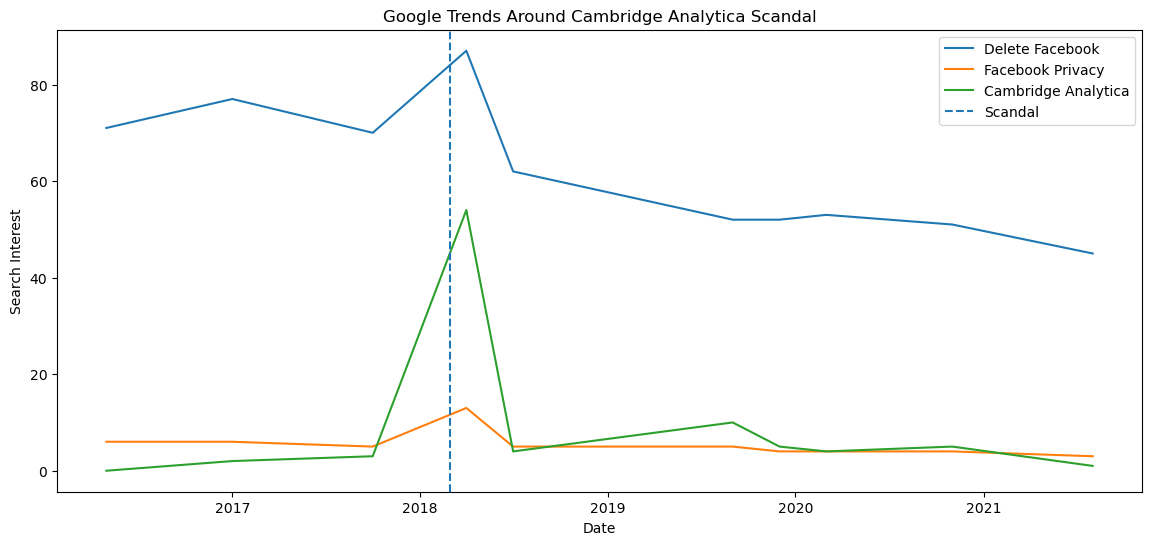

In [34]:
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(14,6))

plt.plot(merged_data["date"], merged_data["delete facebook"], label="Delete Facebook")
plt.plot(merged_data["date"], merged_data["facebook privacy"], label="Facebook Privacy")
plt.plot(merged_data["date"], merged_data["cambridge analytica"], label="Cambridge Analytica")

plt.axvline(pd.to_datetime("2018-03-01"), linestyle="--", label="Scandal")

plt.title("Google Trends Around Cambridge Analytica Scandal")
plt.xlabel("Date")
plt.ylabel("Search Interest")
plt.legend()

plt.show()

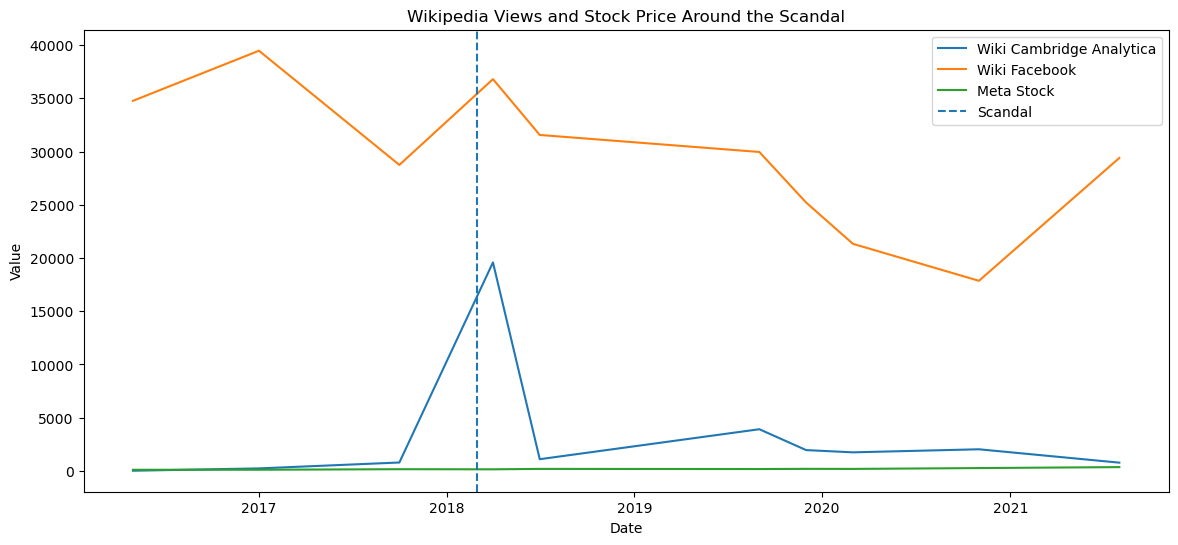

In [35]:
plt.figure(figsize=(14,6))

plt.plot(merged_data["date"], merged_data["Cambridge_Analytica_views"], label="Wiki Cambridge Analytica")
plt.plot(merged_data["date"], merged_data["Facebook_views"], label="Wiki Facebook")
plt.plot(merged_data["date"], merged_data["meta_close"], label="Meta Stock")

plt.axvline(pd.to_datetime("2018-03-01"), linestyle="--", label="Scandal")

plt.title("Wikipedia Views and Stock Price Around the Scandal")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()

plt.show()

In [36]:
merged_data.corr(numeric_only=True)

,delete facebook,facebook privacy,cambridge analytica,Cambridge_Analytica_views,Facebook_views,meta_close
delete facebook,1.000000,0.835351,0.577259,0.539899,0.743204,-0.737319
facebook privacy,0.835351,1.000000,0.921281,0.904982,0.578535,-0.478694
cambridge analytica,0.577259,0.921281,1.000000,0.998618,0.319657,-0.183841
Cambridge_Analytica_views,0.539899,0.904982,0.998618,1.000000,0.288543,-0.150677
Facebook_views,0.743204,0.578535,0.319657,0.288543,1.000000,-0.539132
meta_close,-0.737319,-0.478694,-0.183841,-0.150677,-0.539132,1.000000


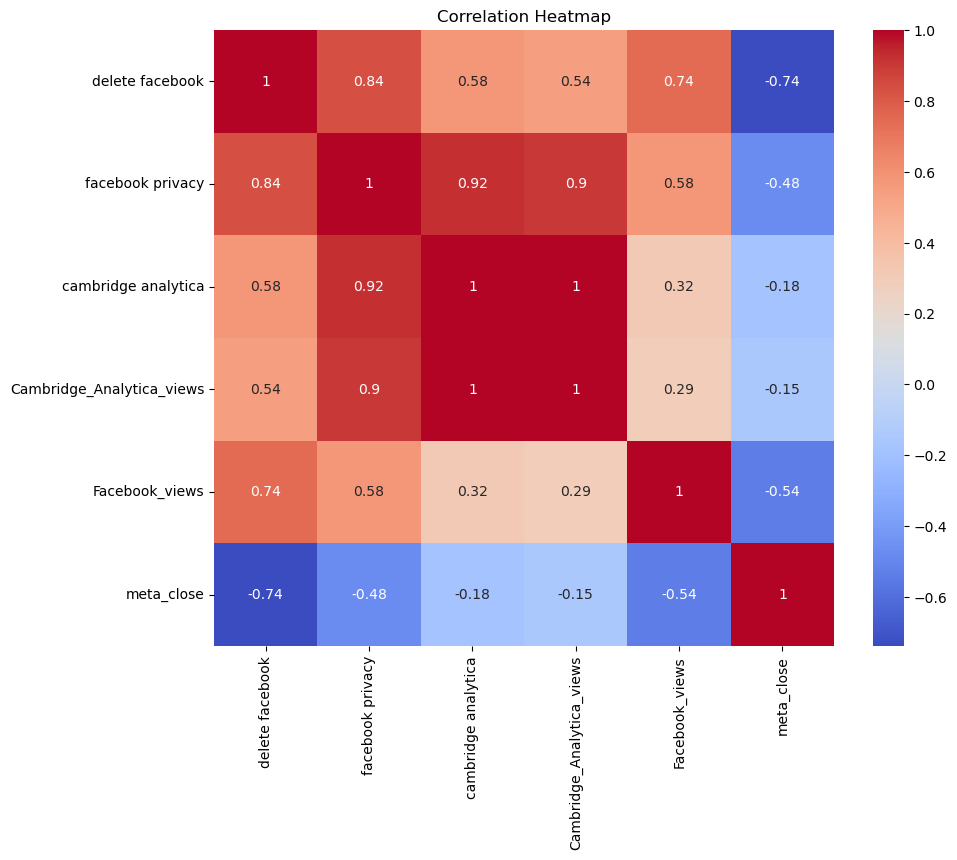

In [37]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(merged_data.corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

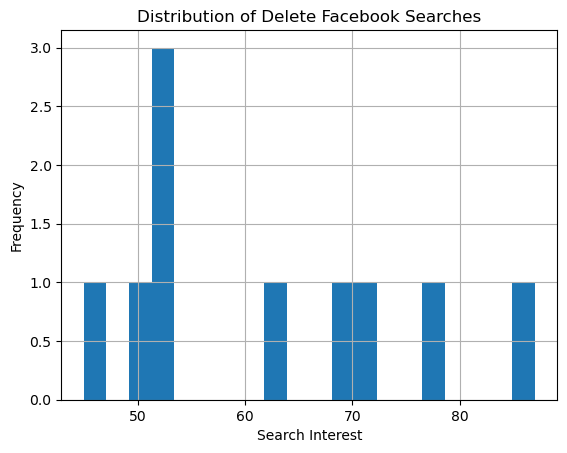

In [38]:
merged_data["delete facebook"].hist(bins=20)
plt.title("Distribution of Delete Facebook Searches")
plt.xlabel("Search Interest")
plt.ylabel("Frequency")
plt.show()

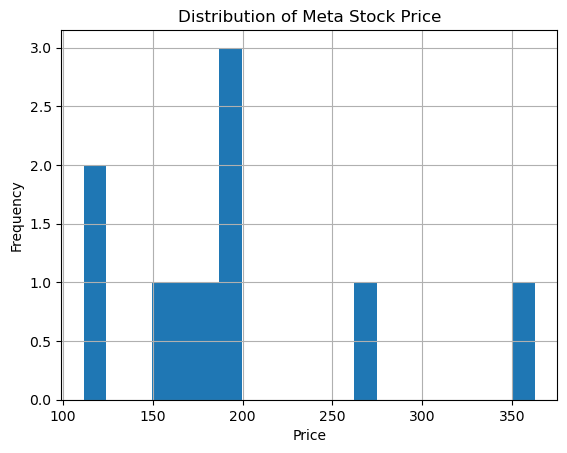

In [39]:
merged_data["meta_close"].hist(bins=20)
plt.title("Distribution of Meta Stock Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

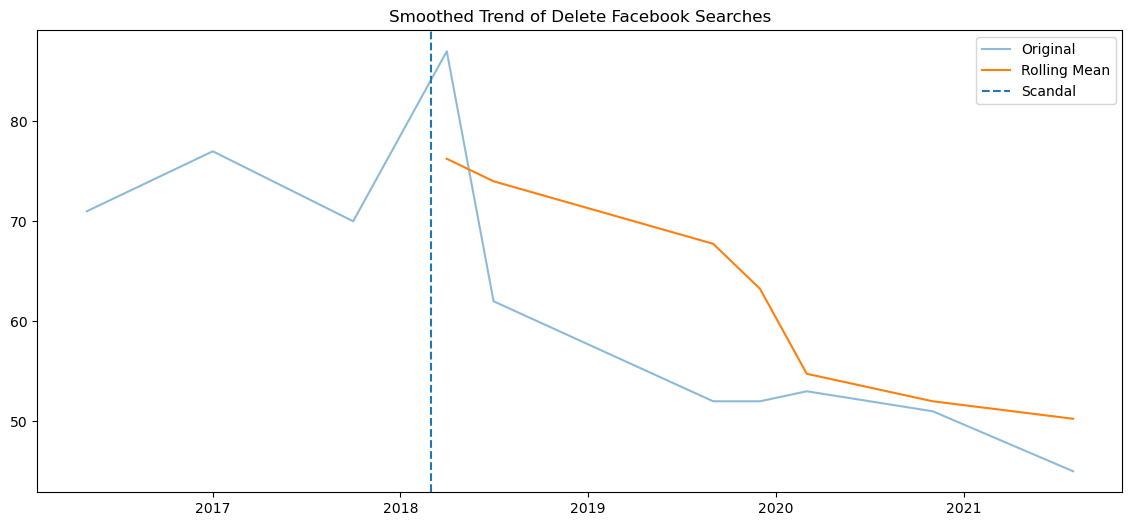

In [40]:
merged_data["delete_fb_rolling"] = merged_data["delete facebook"].rolling(4).mean()

plt.figure(figsize=(14,6))
plt.plot(merged_data["date"], merged_data["delete facebook"], alpha=0.5, label="Original")
plt.plot(merged_data["date"], merged_data["delete_fb_rolling"], label="Rolling Mean")

plt.axvline(pd.to_datetime("2018-03-01"), linestyle="--", label="Scandal")

plt.legend()
plt.title("Smoothed Trend of Delete Facebook Searches")
plt.show()

In [63]:
from scipy.stats import pearsonr

def interpret_corr(r):
    abs_r = abs(r)
    
    if abs_r < 0.2:
        strength = "very weak"
    elif abs_r < 0.4:
        strength = "weak"
    elif abs_r < 0.6:
        strength = "moderate"
    else:
        strength = "strong"
    
    if r > 0:
        direction = "positive"
    elif r < 0:
        direction = "negative"
    else:
        direction = "no"
    
    return strength, direction


def run_corr_test(df, col1, col2, name):
    r, p = pearsonr(df[col1], df[col2])
    strength, direction = interpret_corr(r)
    
    print(name)
    print("r:", round(r, 3))
    print("p-value:", p)
    
    if p < 0.05:
        print("statistically significant")
    else:
        print("not statistically significant")
    
    if direction == "no":
        print("no clear relationship")
    else:
        print(strength, direction, "relationship")
    
    print()

In [64]:
run_corr_test(merged_data, "delete facebook", "Cambridge_Analytica_views", "H1")
run_corr_test(merged_data, "delete facebook", "Facebook_views", "H2")
run_corr_test(merged_data, "facebook privacy", "Cambridge_Analytica_views", "H3")
run_corr_test(merged_data, "facebook privacy", "Facebook_views", "H4")
run_corr_test(merged_data, "cambridge analytica", "Cambridge_Analytica_views", "H5")
run_corr_test(merged_data, "delete facebook", "meta_close", "H6")

H1
r: 0.54
p-value: 0.10719984607054207
not statistically significant
moderate positive relationship

H2
r: 0.743
p-value: 0.013766902900537746
statistically significant
strong positive relationship

H3
r: 0.905
p-value: 0.0003175429550004541
statistically significant
strong positive relationship

H4
r: 0.579
p-value: 0.07975097374757181
not statistically significant
moderate positive relationship

H5
r: 0.999
p-value: 1.5934173210350077e-11
statistically significant
strong positive relationship

H6
r: -0.737
p-value: 0.014955773287489748
statistically significant
strong negative relationship

